In [ ]:

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
model_path = "/content/drive/MyDrive/phishing_pipeline.pkl"

with open(model_path, "rb") as f:
    pipeline = pickle.load(f)

print("Pipeline loaded successfully!")


Pipeline loaded successfully!


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/emails.csv")


In [9]:
df = pd.read_csv("/content/drive/MyDrive/emails.csv")

In [10]:
y_pred = pipeline.predict(X)
y_proba = pipeline.predict_proba(X)[:, 1]


In [11]:
accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9683374476762906


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.97     11322
           1       0.95      0.97      0.96      7312

    accuracy                           0.97     18634
   macro avg       0.97      0.97      0.97     18634
weighted avg       0.97      0.97      0.97     18634



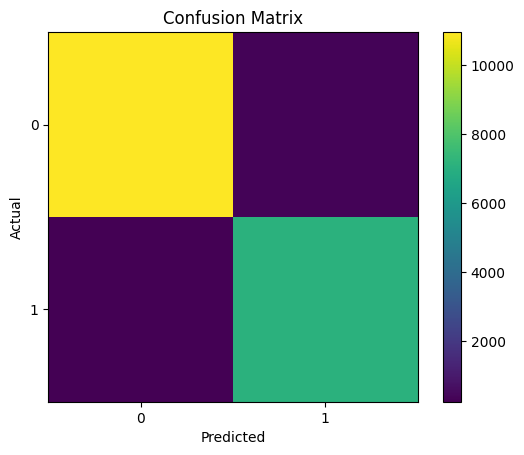

In [13]:
cm = confusion_matrix(y, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.xticks([0,1])
plt.yticks([0,1])
plt.show()


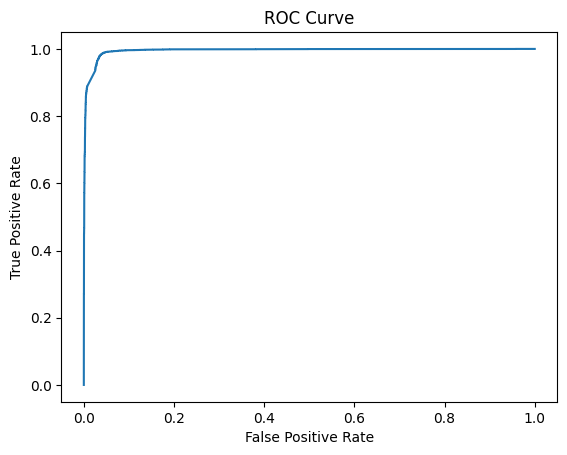

ROC-AUC Score: 0.9950737357256858


In [14]:
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = roc_auc_score(y, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC Score:", roc_auc)


In [15]:
#Samples of Prediction
df["Predicted_Label"] = y_pred
df[["processed_text", "label", "Predicted_Label"]].head(10)


,processed_text,label,Predicted_Label
0,"re : [NUMBER] . [NUMBER] , disc : uniformitari...",0,0
1,the other side of galicismos galicismo is a sp...,0,0
2,re : equistar deal tickets are you still avail...,0,0
3,hello i am your hot lil horny toy. i am the on...,1,1
4,software at incredibly low prices [NUMBER] % l...,1,1
5,global risk management operations sally congra...,0,0
6,"on sun, aug [NUMBER] , [NUMBER] at [NUMBER] : ...",0,0
7,"entourage , stockmogul newsletter ralph velez ...",1,1
8,"we owe you lots of money dear applicant , afte...",1,1
9,re : coastal deal with exxon participation und...,0,0
